In [228]:
from netCDF4 import Dataset
import modeltools.hycom
import abfile.abfile as abf
import gsw
import seawater as sw
import numpy as np
import gridxsec
from datetime import datetime
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm
from datetime import datetime, timedelta

/tmp/ipykernel_3513/2699923850.py:5: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [190]:
lon1, lat1, lon2, lat2 = -19, 79, 12, 79

In [191]:
def read_config():
    DATADIR = "/root/sigma2/betzy_projects_nn9481k/wakamatsut/bioran_v2/data/"

    file_depth = f"{DATADIR}regional.depth.a"
    file_grid = f"{DATADIR}regional.grid.a"

    ab_grid = abf.ABFileGrid(file_grid,"r")
    ab_dpth = abf.ABFileBathy(file_depth,"r",idm=ab_grid.idm,jdm=ab_grid.jdm)

    plon=ab_grid.read_field("plon")
    plat=ab_grid.read_field("plat")
    target_lonlats=[plon,plat]

    mdpth=ab_dpth.read_field('depth')
    maskd=mdpth.data
    maskd[maskd>1e29]=np.nan

    return plon, plat, mdpth

In [192]:
plon, plat, mdpth = read_config()
sec = gridxsec.Section([lon1,lon2],[lat1,lat2],plon,plat) # get grand circle

I,J=sec.grid_indexes
dist=sec.distance
slon=sec.longitude
slat=sec.latitude

In [193]:
def custom_div_cmap(numcolors=11, name='custom_div_cmap',
                    mincol='blue', midcol='white', maxcol='red'):
    """ Create a custom diverging colormap with three colors
    
    Default is blue to white to red with 11 colors.  Colors can be specified
    in any way understandable by matplotlib.colors.ColorConverter.to_rgb()
    """

    from matplotlib.colors import LinearSegmentedColormap 
    
    cmap = LinearSegmentedColormap.from_list(name=name, 
                                             colors =[mincol, midcol, maxcol],
                                             N=numcolors)
    return cmap

In [194]:
def plot_section(plon,plat,mdpth,slon,slat,label,list_extent,projection):
    figsize=(8,8)

    base_cmap = colormaps['Blues']
    sub_cmap = base_cmap(np.linspace(0.1, 0.6, 256))  # reversed 0–30%
    cmap = LinearSegmentedColormap.from_list('cmap', sub_cmap)
    
    crs_latlon = ccrs.PlateCarree()
    ig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': projection})
    ax.set_extent(list_extent, crs=crs_latlon)
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black',linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='palegoldenrod')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue',alpha=0.3)
    pcm = ax.pcolormesh(plon,plat,mdpth,vmin=0,vmax=5000,cmap=cmap, shading='auto',transform=crs_latlon)
    ax.plot(slon,slat,"r-",lw=2,transform=crs_latlon)
    plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.7, pad=0.1, label=label)

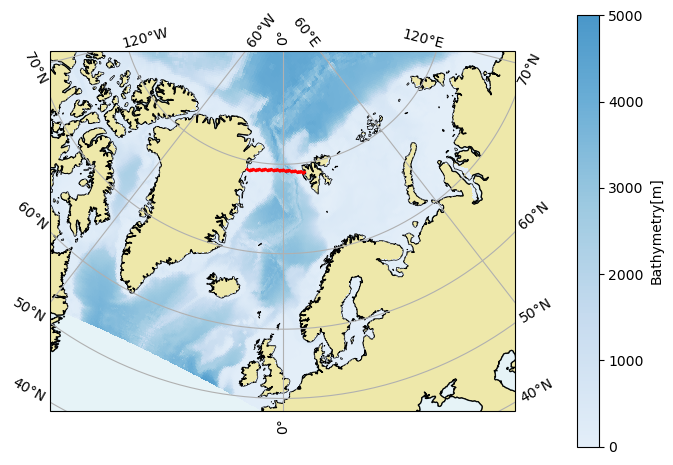

In [195]:
list_extent = (-55, 55, 48, 88)
projection = ccrs.LambertConformal(central_longitude=0, central_latitude=60)
label = "Bathymetry[m]"

plot_section(plon,plat,mdpth,slon,slat,label,list_extent,projection)

In [196]:
def get_filename(date_str):
    DATADIR = "/root/sigma2/betzy_projects_nn9481k/wakamatsut/bioran_v2/data/"
    yyyy = date_str[0:4]
    dt = datetime.strptime(date_str, "%Y-%m-%d")
    doy = dt.timetuple().tm_yday
    hdate = f"{yyyy}_{doy}_12"  
    #print(doy)
    #print(hdate)
    archmfile=f"{DATADIR}archm.{hdate}.a"
    cicefile = f"{DATADIR}cice/iceh.{date_str}.nc"

    return archmfile, cicefile

In [197]:
filetype="archive"
dpname = modeltools.hycom.layer_thickness_variable[filetype]
print(dpname)

x=dist/1000.
xlab="Distance along section[km]"

thknss


In [205]:
date_str = "2016-09-03"
variable = "density"
label = "Potential density []"
#variable = "temp"
#label = "Temperature [degree C]"
archmfile, cicefile = get_filename(date_str)

i_abfile = abf.ABFileArchv(archmfile,"r")
kdm=max(i_abfile.fieldlevels)
print(kdm)

50


In [233]:
dens = (variable == "density")

xx=np.zeros((kdm+1,I.size))
intfsec=np.zeros((kdm+1,I.size))
if dens:
    datasec_sal=np.zeros((kdm+1,I.size))
    datasec_temp=np.zeros((kdm+1,I.size))
    sigma_sec=np.zeros((kdm+1,I.size))
else:
    datasec=np.zeros((kdm+1,I.size))

for k in range(kdm) :
    dp2d=i_abfile.read_field(dpname,k+1)
    dp2d=np.ma.filled(dp2d,0.)/modeltools.hycom.onem
    intfsec[k+1,:] = intfsec[k,:] + dp2d[J,I]
    
    if dens:
        data2d_sal=i_abfile.read_field('salin',k+1)
        data2d_sal=np.ma.filled(data2d_sal,1e30)
        if k==0 : datasec_sal[k,:] = data2d_sal[J,I]
        datasec_sal[k+1,:] = data2d_sal[J,I]

        data2d_temp=i_abfile.read_field('temp',k+1)
        data2d_temp=np.ma.filled(data2d_temp,1e30)
        if k==0 : datasec_temp[k,:] = data2d_temp[J,I]
        datasec_temp[k+1,:] = data2d_temp[J,I]
    else:
        data2d=i_abfile.read_field(variable,k+1)
        data2d=np.ma.filled(data2d,1e30)
        if k==0 : datasec[k,:] = data2d[J,I]
        datasec[k+1,:] = data2d[J,I]

i_maxd=np.argmax(np.abs(intfsec[kdm,:]))

for k in range(kdm+1) :
    xx[k,:] = x[:]

if dens:
    datasec_sal = np.ma.masked_where(datasec_sal>0.5*1e30,datasec_sal)
    datasec_temp = np.ma.masked_where(datasec_temp>0.5*1e30,datasec_temp)
#    SA = gsw.SA_from_SP(datasec_sal, p=0, lon=0, lat=0)
#    CT = gsw.CT_from_pt(SA, datasec_temp)
#    sigma_sec = gsw.sigma0(SA, CT)
    datasec_pres = np.zeros_like(datasec_temp)
    sigma_sec = sw.pden(datasec_sal, datasec_temp, datasec_pres) - 1000
    sigma_sec = np.ma.masked_where(sigma_sec<0.0,sigma_sec)
    datasec=sigma_sec
else:
    datasec = np.ma.masked_where(datasec>0.5*1e30,datasec)

clim=[datasec.min(),datasec.max()]
print("clim=",clim[0], clim[1])

clim= 24.35691708304421 28.1308891849842


Text(0.5, 0, 'Distance along section[km]')

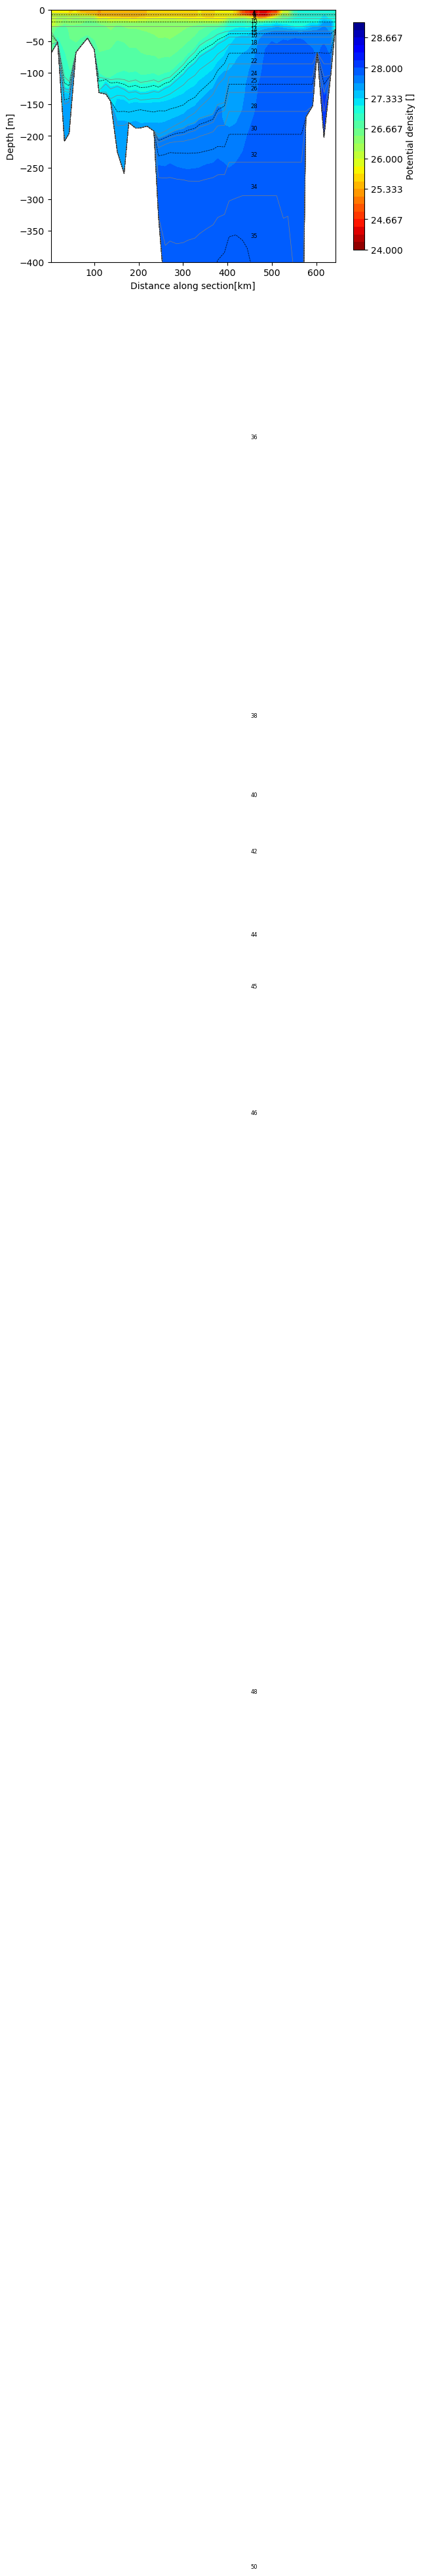

In [234]:
isinterface=True

figsize=(7,5)
ig, ax = plt.subplots(figsize=figsize)

# Control colormap
if variable == "temperature":
    cmap = colormaps['coolwarm']
    levels = np.linspace(-2, 5.5, 31)  # finer resolution
    #ticks = np.arange(-2.0, 5.6, 1.0)  # custom tick labels
elif variable == "density":
    cmap = colormaps['jet'].reversed()
    levels = np.linspace(24, 29, 31)

# Plot contour
pcm = ax.contourf(xx,-intfsec,datasec,cmap=cmap,levels=levels)
plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.9, pad=0.05, label=label)

# Plot layer interfaces
if isinterface:
    for k in range(1,kdm+1) :
         if k%100 == 0 : 
            PL=ax.plot(x,-intfsec[k,:],"-",color="k")
            textx = x[i_maxd]
            texty = -0.5*(intfsec[k-1,i_maxd] + intfsec[k,i_maxd])
            ax.text(textx,texty,str(k),verticalalignment="center",horizontalalignment="center",fontsize=6)
         elif k%5 == 0 : 
            PL=ax.plot(x,-intfsec[k,:],"--",color="k", linewidth=0.5)
            textx = x[i_maxd]
            texty = -0.5*(intfsec[k-1,i_maxd] + intfsec[k,i_maxd])
            ax.text(textx,texty,str(k),verticalalignment="center",horizontalalignment="center",fontsize=6)
         else :
            if k > 2 and k%2== 0 :
               PL=ax.plot(x,-intfsec[k,:],"-",color=".5",linewidth=0.5)
               textx = x[i_maxd]
               texty = -0.5*(intfsec[k-1,i_maxd] + intfsec[k,i_maxd])
               ax.text(textx,texty,str(k),verticalalignment="center",horizontalalignment="center",fontsize=6)
            else :
               continue

# axis labels
ax.set_ylim(-400, 0)   
ax.set_ylabel('Depth [m]')
ax.set_xlabel(xlab)